**Smart Student Performance Predictor**

The **Smart Student Performance Predictor** is a machine learning project that analyzes lifestyle and academic data from 40,000 students to predict their future success.

It uses **Regression** to forecast a student's exact numerical upcoming grade and **Classification** to instantly flag whether they are on track to pass or fail.

The final system features an **Interactive Report Card** that takes live student stats, outputs immediate performance predictions, and automatically generates custom advice to help them improve.

: ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡ ➡

**Library Imports**
Imports essential Python data science tools: **pandas** and **numpy** for data manipulation, and **matplotlib.pyplot** and **seaborn** for generating charts.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

**Mounting Drive & Loading Data**
Mounts Google Drive to access your cloud files and reads the dataset **student_performance_prediction.csv** into a Pandas DataFrame **(df)**, showing the first 5 rows.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

path = "/content/drive/MyDrive/dataset/student_performance_prediction.csv"

df = pd.read_csv(path)

df.head()

Mounted at /content/drive


,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


**Checking Dataset Dimensions**
Runs **df.shape** to see how large the dataset is. It reveals the data contains 40,000 rows (students) and 7 columns (features).

In [3]:
print(df.shape)

(40000, 7)


**Statistical Summary**
Runs **df.describe()** to get a quick statistical breakdown (mean, standard deviation, min, max) of the numerical columns.

**⚠️ Note: This step subtly flags realistic data anomalies (like a negative minimum for study hours or a max attendance rate of 150%).**

In [4]:
df.describe()

,Study Hours per Week,Attendance Rate,Previous Grades
count,38005.000000,38008.000000,38006.000000
mean,9.962744,75.276323,65.440107
std,5.031154,20.393418,16.503119
min,-12.300000,-14.300000,8.300000
25%,6.600000,61.600000,55.100000
50%,10.000000,75.300000,65.200000
75%,13.400000,88.800000,75.200000
max,32.400000,150.200000,200.000000


Data Structure Inspection
Runs **df.info()**, which lists all column names, their data types (numeric vs. text/object), and how many valid (non-null) entries exist per column.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   40000 non-null  object 
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              38008 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  38000 non-null  object 
 5   Parent Education Level                       38000 non-null  object 
 6   Passed                                       38000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 2.1+ MB


**Identifying Missing Values**
Runs **df.isnull().sum()** to count exactly how many missing (NaN) values exist in each column. Every feature has roughly 2,000 missing data points.

In [6]:
print(df.isnull().sum())

Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64


**Imputing Missing Numerical Data**
Loops through all numerical columns and fills in their missing values using the mean (average) of that column.

In [7]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_3025/4057150236.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


**Imputing Missing Categorical Data**
Loops through all text/object columns (like "Passed" or "Parent Education Level") and fills missing values using the mode (the most frequently occurring value).

In [8]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_3025/2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


**Double-Checking Missing Values**
Re-runs **df.isnull().sum()** to verify that all missing values have been successfully handled (all counts are now 0).

In [9]:
print(df.isnull().sum())

Student ID                                     0
Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64


**Removing Duplicates**
Applies **df.drop_duplicates()** to ensure identical rows are stripped out of the dataset to prevent model bias.

In [10]:
df.drop_duplicates(inplace=True)

**Categorical Encoding**
Uses **LabelEncoder** from **scikit-learn** to convert text categories (like "Yes/No" or education tiers) into numbers so the mathematical models can understand them.

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

**Saving Clean Data**
Exports the polished, fully numerical dataset into a new file named **cleaned_student_data.csv.**

In [12]:
df.to_csv("cleaned_student_data.csv", index=False)

Verifying Encoded Data
Prints **df.head()** to check the finalized dataframe structure before moving into analysis.

In [13]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,0,12.5,75.276323,75.0,1,4,1
1,1,9.3,95.300000,60.6,0,3,0
2,2,13.2,75.276323,64.0,0,0,0
3,3,17.6,76.800000,62.4,1,1,0
4,4,8.8,89.300000,72.7,0,4,0


DAY 2 - **EXPLORATORY DATA ANALYSIS**

**Feature Distributions**
Plots histograms **(df.hist())** for all variables to visually understand how values like study hours and grades spread across the student population.

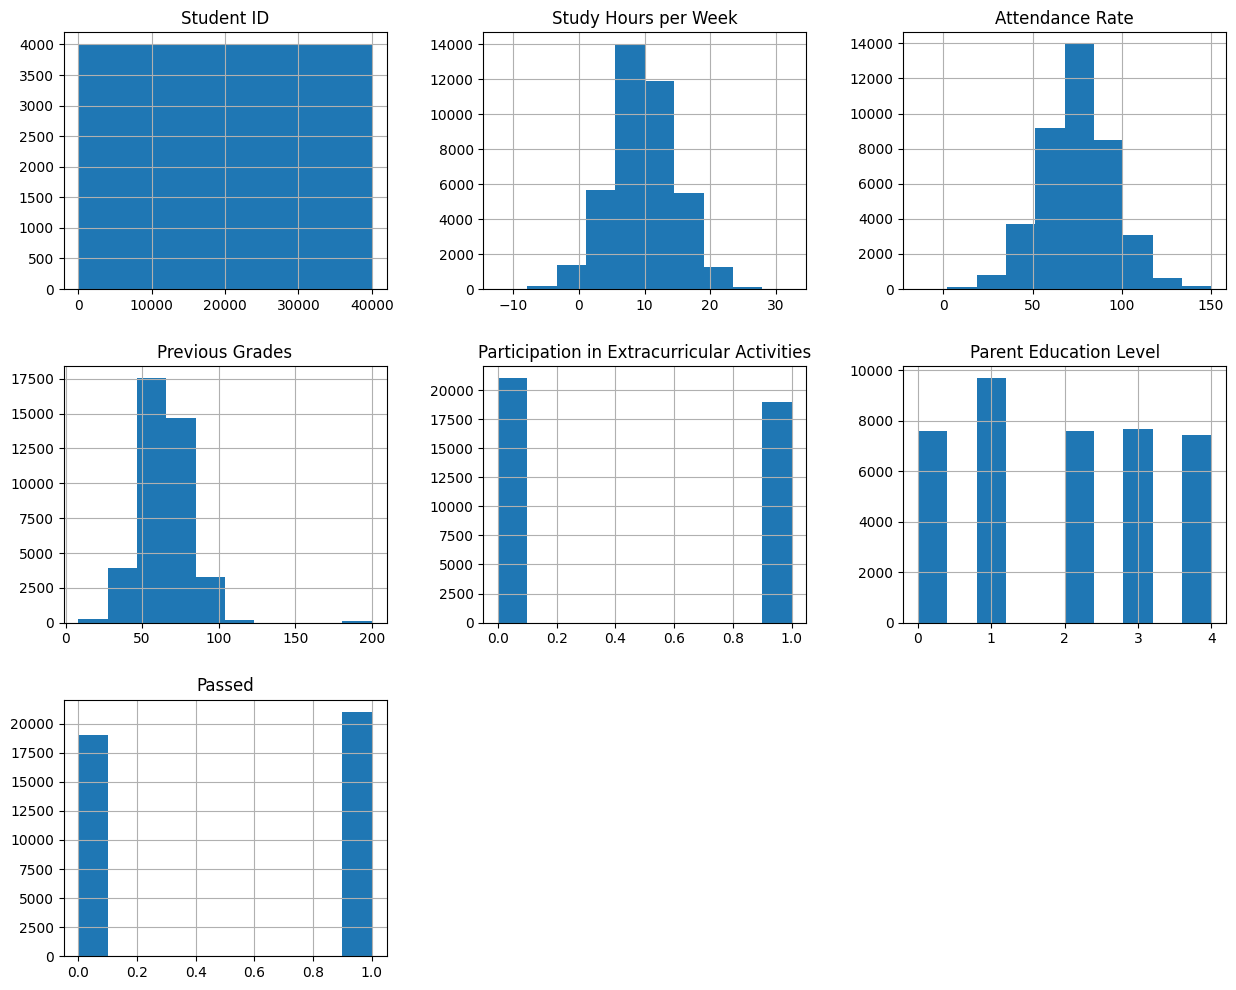

In [14]:
df.hist(figsize=(15,12))

plt.show()

**Correlation Heatmap**
Generates a correlation matrix heatmap to see how tightly variables move together (e.g., how strongly study hours correlate with passing).

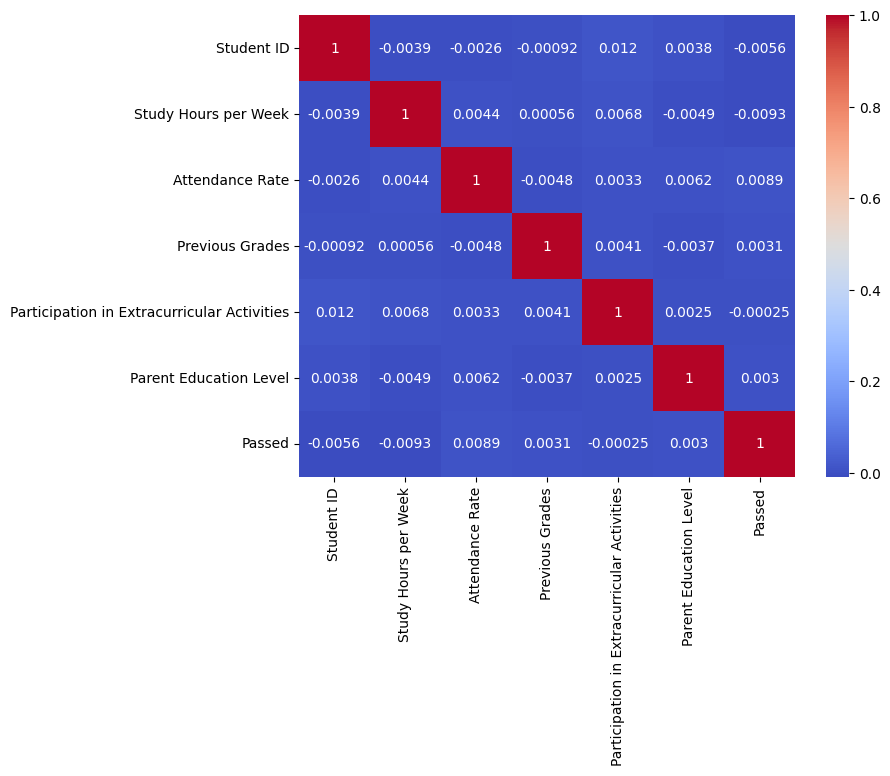

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Scatter Plot** (Hours vs. Grades)
Creates a scatter plot comparing weekly study hours against previous grades to check for visible trends or patterns.

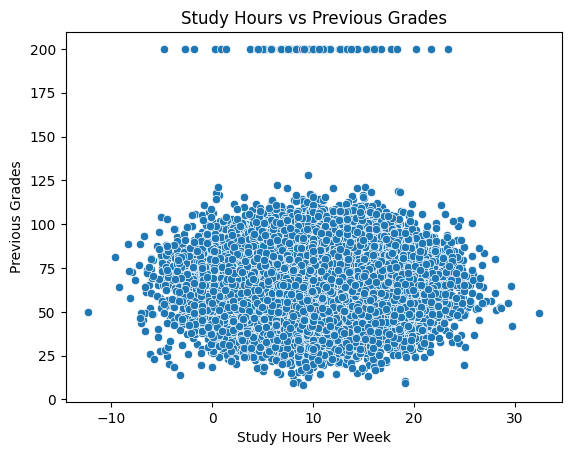

In [16]:
sns.scatterplot(
    x=df['Study Hours per Week'],
    y=df['Previous Grades']
)

plt.xlabel("Study Hours Per Week")

plt.ylabel("Previous Grades")

plt.title("Study Hours vs Previous Grades")

plt.show()

**Box Plot (Attendance vs. Passing)**
Plots a box plot to analyze if students who "Passed" (1) have visibly higher attendance rates than those who "Failed" (0).

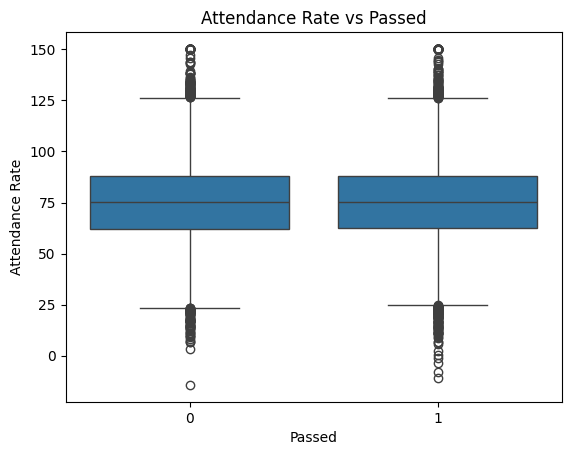

In [17]:
sns.boxplot(
    x=df['Passed'],
    y=df['Attendance Rate']
)

plt.xlabel("Passed")

plt.ylabel("Attendance Rate")

plt.title("Attendance Rate vs Passed")

plt.show()

**Distribution of Parent Education**
Generates a bar chart tracking the distribution of the different parental education levels across the dataset.

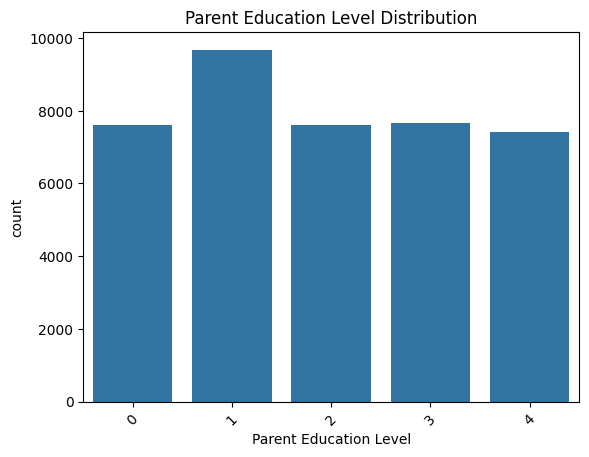

In [18]:
sns.countplot(
    x=df['Parent Education Level']
)

plt.xticks(rotation=45)

plt.title("Parent Education Level Distribution")

plt.show()

**Activity vs. Success & Target Balance**
Plots counts comparing extracurricular activity against passing rates, and prints **value_counts() **to verify if the dataset is balanced between passing students (21,011) and failing students (18,989).

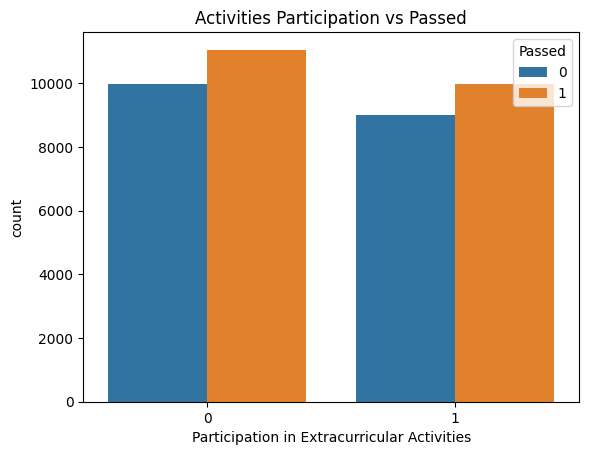

Passed
1    21011
0    18989
Name: count, dtype: int64


In [19]:
sns.countplot(
    x='Participation in Extracurricular Activities',
    hue='Passed',
    data=df
)

plt.title("Activities Participation vs Passed")
plt.show()
print(df['Passed'].value_counts())

**Pass/Fail Distribution Charts**
Visualizes the target variable balance using basic count plots.

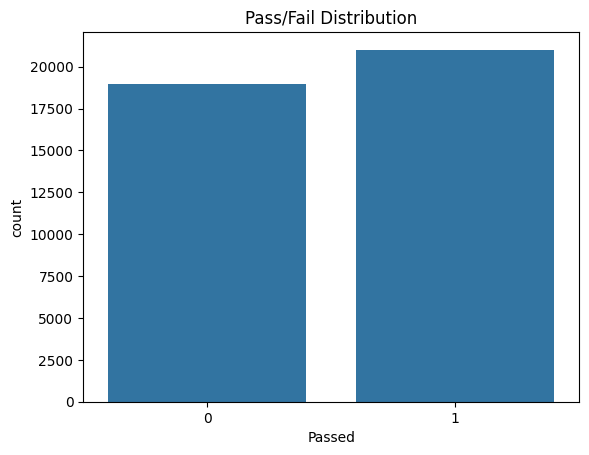

In [20]:
sns.countplot(
    x=df['Passed']
)

plt.title("Pass/Fail Distribution")

plt.show()

**Feature Engineering**
Creates a brand-new hybrid feature: **Study Attendance Score** (by multiplying Study Hours $\times$ Attendance Rate) to capture a combined metric of student effort.

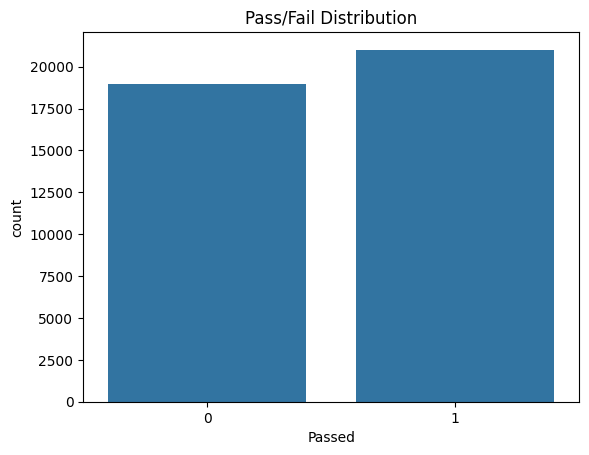

In [21]:
sns.countplot(
    x=df['Passed']
)

plt.title("Pass/Fail Distribution")

plt.show()

**Visualizing Engineered Feature**
Plots the new Study Attendance Score against Previous Grades to check if this combined metric has a stronger relationship with performance.

**Regression Modeling (Predicting Scores)**

**Synthesizing the Target Variable**
Artificially constructs a continuous target column called Future Grade using a mathematical formula combining previous grades, weighted study hours, weighted attendance, and random Gaussian noise **(np.random.normal).**

In [22]:
df['Study Attendance Score'] = (
    df['Study Hours per Week'] *
    df['Attendance Rate']
)

**Splitting Features and Target**
Separates the data into features **(X - dropping IDs and the target)** and the target variable **(y - Future Grade).**

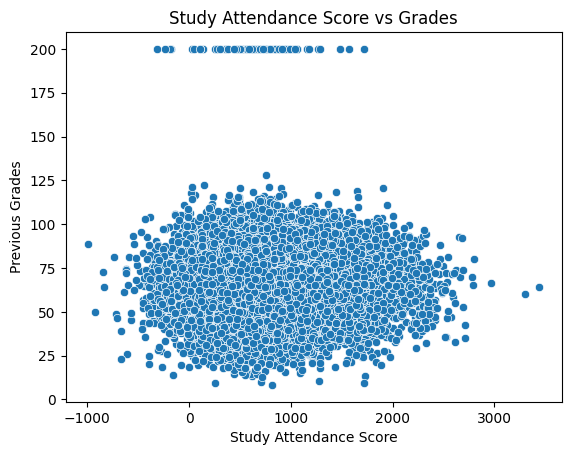

In [23]:
sns.scatterplot(
    x=df['Study Attendance Score'],
    y=df['Previous Grades']
)

plt.title("Study Attendance Score vs Grades")

plt.show()

**Train-Test Split**
Divides the data into an 80% training set (to teach the model) and a 20% testing set (to evaluate it), using a fixed **random_state=42** for consistency.

In [24]:
import numpy as np

df['Future Grade'] = (
    df['Previous Grades']
    + (df['Study Hours per Week'] * 0.8)
    + (df['Attendance Rate'] * 0.2)
    + np.random.normal(0, 5, len(df))
)

**Feature Scaling**
Applies **StandardScaler** to normalize the scales of all features so that variables with larger numbers don't unfairly skew the linear model.

In [25]:
X = df.drop(
    ['Student ID', 'Future Grade'],
    axis=1
)

y = df['Future Grade']

**Training Linear Regression**
Initializes and trains **(.fit())** a LinearRegression model using the scaled training data to map inputs to continuous future grades.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Generating Predictions**
Uses the trained model to predict future grades for the hidden test data subset **(X_test_scaled)**.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Evaluating Regression Performance**
Calculates the Root Mean Squared Error **(RMSE $\approx$ 5.01) **and the R² Score **($\approx$ 0.925)**, indicating that the model explains roughly 92.5% of the variance in future grades.

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

**Actual vs. Predicted Scatter Plot**
Plots actual test grades against predicted test grades. The tight diagonal linear layout demonstrates strong predictive accuracy.

In [29]:
lr_pred = lr.predict(X_test_scaled)

In [30]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

rmse_lr = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

r2_lr = r2_score(y_test, lr_pred)

print("Linear Regression RMSE:", rmse_lr)

print("Linear Regression R2 Score:", r2_lr)

Linear Regression RMSE: 5.001900850902996
Linear Regression R2 Score: 0.9255246627543142


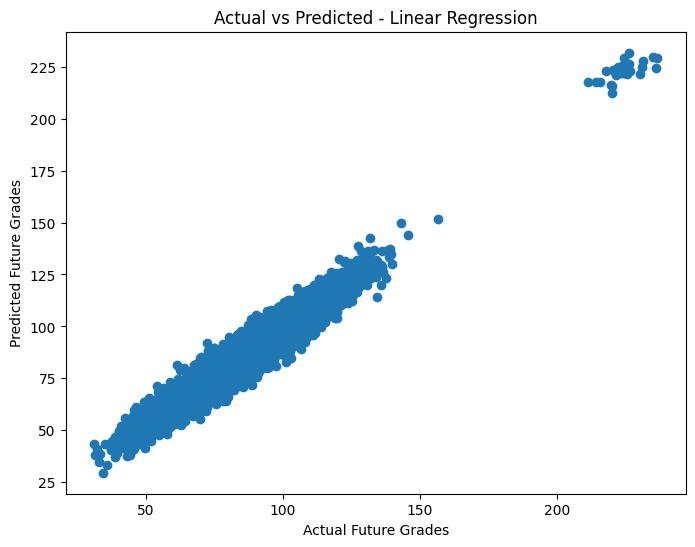

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Future Grades")

plt.ylabel("Predicted Future Grades")

plt.title("Actual vs Predicted - Linear Regression")

plt.show()

**Comparison Table**
Creates a dataframe displaying side-by-side examples of the Actual synthesized grade versus what the Linear Regression model predicted.

In [32]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': lr_pred
})

print(comparison_df.head(20))

        Actual   Predicted
0    71.235075   71.094319
1    85.238781   94.431609
2   103.337175  100.582489
3    68.427468   78.856952
4   111.969871  119.119492
5    79.104477   82.966551
6    98.960795  100.836774
7   111.076871  112.658646
8    82.072181   81.374265
9    93.125510   86.279344
10   93.791052   90.436689
11   70.939680   75.218759
12  105.262678   95.517939
13   61.904538   56.513653
14   53.376536   50.895114
15  111.197386  103.630368
16   75.142571   86.153922
17   95.812983  102.075350
18   97.344084   99.221305
19   78.788057   80.881076


**Residual Plot**
Plots the residual errors (Actual minus Predicted). It checks if errors are scattered randomly around zero, which validates the linear model's assumptions.

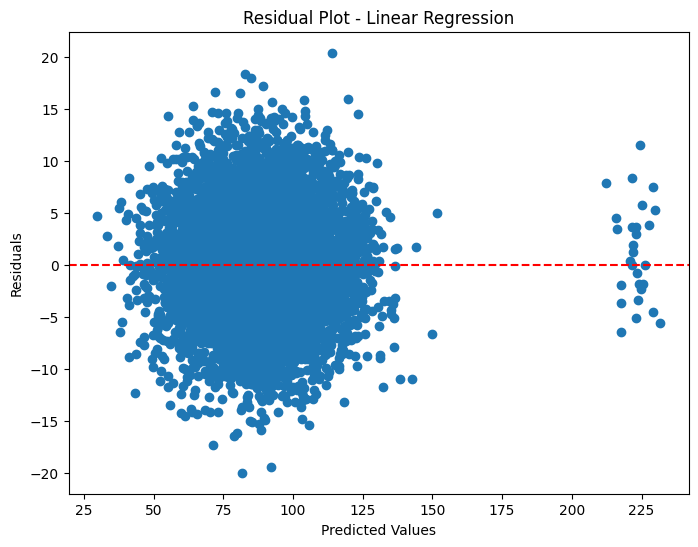

In [33]:
residuals = y_test - lr_pred

plt.figure(figsize=(8,6))

plt.scatter(lr_pred, residuals)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot - Linear Regression")

plt.show()

**Residual Error Distribution**
Generates a histogram with a Kernel Density Estimate (KDE) curve to verify that the prediction errors are normally distributed (forming a clean bell curve).

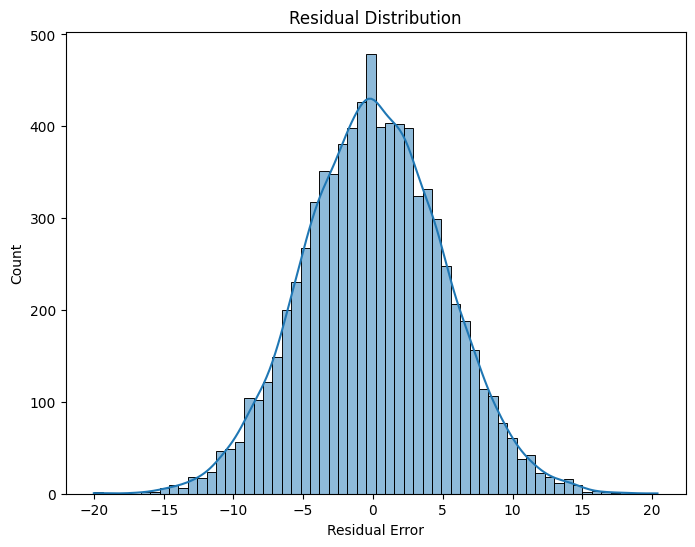

In [34]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.show()

DAY 3 - **Classification Modeling (Predicting Pass/Fail)**

**Defining Classification Variables**
Resets X and y specifically for classification, mapping inputs to the binary Passed column (1 for Pass, 0 for Fail).

In [35]:
X = df.drop(
    ['Student ID', 'Passed', 'Future Grade'],
    axis=1
)

y = df['Passed']

**Train-Test Split (Classification)**
Splits the classification features into an 80/20 train/test split.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Feature Scaling**
Standardizes the training and testing sets for classification.

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Training Logistic Regression**
Trains a** LogisticRegression** model, which calculates probabilities to classify whether a student will pass or fail.

In [38]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression()

**Classification Predictions**
Generates binary (0 or 1) outcomes for the test set.

In [39]:
log_pred = log_model.predict(
    X_test_scaled
)

**Evaluation Metrics**
Prints critical performance evaluations: Accuracy (52.6%), Precision (52.6%), Recall (99.5%), and F1-Score (68.8%).

**⚠️ Critical Discovery: Notice that Recall is nearly 100% while accuracy hovers around 52%. This indicates a flawed model that is simply guessing "Pass" (1) for almost every single student.**

In [40]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print(
    "Accuracy:",
    accuracy_score(y_test, log_pred)
)

print(
    "Precision:",
    precision_score(y_test, log_pred)
)

print(
    "Recall:",
    recall_score(y_test, log_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, log_pred)
)

Accuracy: 0.5265
Precision: 0.5262826961770624
Recall: 0.9950071326676176
F1 Score: 0.6884355979601908


**CONFUSION** **MATRIX HEATMAP**
Plots a confusion matrix visualizing True Positives, False Positives, True Negatives, and False Negatives. This visually confirms the flaw—the model has an incredibly high rate of False Positives.

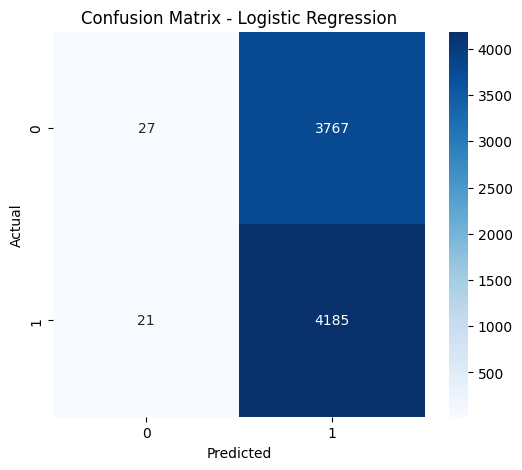

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    log_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

**Comparison View**
Prints a comparison dataframe displaying actual pass status vs. predicted status. You can see a column filled almost entirely with 1s.

In [42]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': log_pred
})

print(comparison_df.head(50))

    Actual  Predicted
0        1          1
1        1          1
2        1          1
3        0          1
4        0          1
5        1          1
6        0          1
7        0          1
8        1          1
9        1          1
10       1          1
11       0          1
12       1          1
13       1          1
14       0          1
15       0          1
16       1          1
17       1          1
18       0          1
19       1          1
20       0          1
21       0          1
22       1          1
23       0          1
24       1          1
25       1          1
26       0          1
27       1          1
28       1          1
29       1          1
30       0          1
31       1          1
32       1          1
33       0          1
34       1          1
35       0          0
36       1          1
37       1          1
38       1          1
39       1          1
40       1          1
41       1          1
42       1          1
43       0          1
44       1

**Actual vs. Predicted Class Distribution**
Plots side-by-side bar charts comparing the balanced distribution of actual student outcomes against the highly skewed, entirely "Passed" predictions of the model.

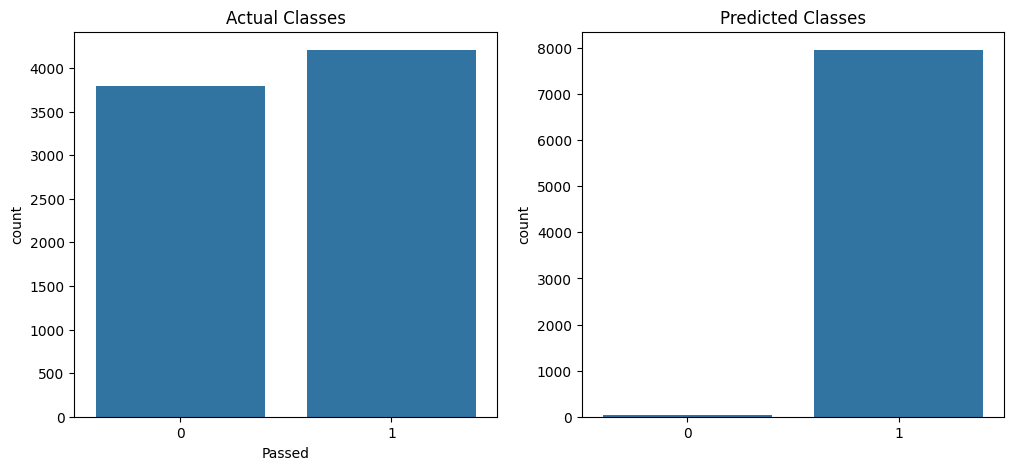

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    x=y_test,
    ax=axes[0]
)

axes[0].set_title("Actual Classes")

sns.countplot(
    x=log_pred,
    ax=axes[1]
)

axes[1].set_title("Predicted Classes")

plt.show()

**Building the Interactive Prediction System**

FUTURE GRADE - LINEAR REGRESSION


**Retraining Clean Independent Pipelines**
Isolates and cleanly retrains both the continuous Linear Regression system **(lr) **and the binary Logistic Regression system** (log_model) **so they are simultaneously ready to handle manual input data.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X_reg = df.drop(
    ['Student ID', 'Future Grade', 'Passed'],
    axis=1
)

y_reg = df['Future Grade']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

X_test_reg_scaled = scaler_reg.transform(X_test_reg)

lr = LinearRegression()

lr.fit(X_train_reg_scaled, y_train_reg)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [45]:
from sklearn.linear_model import LogisticRegression

X_clf = df.drop(
    ['Student ID', 'Passed', 'Future Grade'],
    axis=1
)

y_clf = df['Passed']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)

X_test_clf_scaled = scaler_clf.transform(X_test_clf)

log_model = LogisticRegression()

log_model.fit(
    X_train_clf_scaled,
    y_train_clf
)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


**Interactive System & Recommendation Engine**
This cell executes an interactive user prompt block. It performs the following sequence:

Collects live user inputs via **input() **commands (Study hours, attendance, prior grades, activities, parent education level).

Packages inputs into a clean DataFrame structure matching the models' expectations.

Transforms and scales the new data inputs.

Automatically prints a Student Performance Report showing the predicted score, pass status, and exact probability.

Evaluates conditional statements **(if blocks)** to print customized warning or praise recommendations based on the student's metrics.

In [46]:
# !pip install gradio  # Run this in a new cell if you haven't installed Gradio yet

import gradio as gr
import pandas as pd
import numpy as np

# Custom CSS targeting your specific Cyber Grape theme elements
custom_css = """
body, .gradio-container {
    background-color: #121212 !important;
    color: #E0E0E0 !important;
    font-family: 'Inter', sans-serif;
}
.gr-box, .gr-panel, .gr-card {
    background-color: #1E1E1E !important;
    border: 1px solid #4A148C !important;
    border-radius: 8px;
}
label, .gr-form-label {
    color: #7B1FA2 !important;
    font-weight: bold !important;
}
input, select, .gr-text-input {
    background-color: #121212 !important;
    color: #FFFFFF !important;
    border: 1px solid #7B1FA2 !important;
}
/* Styling the special accent metric outputs */
#pass-flag {
    color: #00E676 !important;
    font-weight: 800;
    font-size: 1.5em;
}
#fail-flag {
    color: #FF5252 !important;
    font-weight: 800;
    font-size: 1.5em;
}
"""

def predict_student_performance(study_hours, attendance, previous_grades, activities, parent_education):
    # 1. Map inputs exactly to match model requirements
    act_binary = 1 if activities == "Yes" else 0
    edu_map = {"High School": 0, "Associate": 1, "Bachelor": 2, "Master": 3, "Other": 4}
    edu_encoded = edu_map.get(parent_education, 1)

    study_attendance_score = study_hours * attendance

    # 2. Package into structured DataFrame
    sample = pd.DataFrame({
        'Study Hours per Week': [study_hours],
        'Attendance Rate': [attendance],
        'Previous Grades': [previous_grades],
        'Participation in Extracurricular Activities': [act_binary],
        'Parent Education Level': [edu_encoded],
        'Study Attendance Score': [study_attendance_score]
    })

    # 3. Transform data using pipelines from previous cells
    sample_reg_scaled = scaler_reg.transform(sample)
    sample_clf_scaled = scaler_clf.transform(sample)

    # 4. Machine Learning Inference
    future_grade = lr.predict(sample_reg_scaled)[0]
    pass_prediction = log_model.predict(sample_clf_scaled)[0]
    pass_probability = log_model.predict_proba(sample_clf_scaled)[0][1] * 100

    # 5. Structure dynamic styling for the Target Flag (Highlighting flawed model outputs)
    result_str = "PASS" if pass_prediction == 1 else "FAIL"
    html_flag_id = "pass-flag" if result_str == "PASS" else "fail-flag"

    report_html = f"""
    <div style='padding: 15px; border-radius: 5px; background-color: #1E1E1E;'>
        <h3 style='color: #4A148C; margin-top: 0;'>📊 Predicted Future Grade</h3>
        <p style='font-size: 2em; font-weight: bold; margin: 5px 0; color: #FFFFFF;'>{future_grade:.2f}</p>

        <h3 style='color: #4A148C;'>🎯 Classification Result</h3>
        <p>Status: <span id='{html_flag_id}'>{result_str}</span></p>
        <p style='font-size: 0.9em; color: #B0B0B0;'>Confidence Passing Likelihood: <strong>{pass_probability:.2f}%</strong></p>
    </div>
    """

    # 6. Generate Rule-Based Custom Advice
    recommendations = []
    if study_hours < 5:
        recommendations.append("• ⏰ <strong>Time Management:</strong> Critical need to increase weekly study hours.")
    if attendance < 75:
        recommendations.append("• 🏫 <strong>Attendance Alert:</strong> Low attendance rate strongly jeopardizing core comprehension.")
    if previous_grades < 50:
        recommendations.append("• 👥 <strong>Mentorship Required:</strong> Peer academic mentoring is recommended to bridge knowledge gaps.")
    if future_grade < 60:
        recommendations.append("• 🚨 <strong>Risk Mitigation:</strong> Predicted score sits below passing margins. Deploy structural intervention support.")
    if attendance >= 85 and study_hours >= 8:
        recommendations.append("• ⭐ <strong>Excellent Habits:</strong> Commendable study metrics sustained. Keep pushing!")

    if not recommendations:
        recommendations.append("• Balanced routine detected. Maintain status-quo while pushing for optimization.")

    recommendations_html = f"""
    <div style='padding: 15px; border-radius: 5px; background-color: #1E1E1E;'>
        <h3 style='color: #4A148C; margin-top: 0;'>💡 Automated System Advice</h3>
        <div style='color: #E0E0E0; line-height: 1.6;'>{'<br>'.join(recommendations)}</div>
    </div>
    """

    return report_html, recommendations_html

# Constructing layout
with gr.Blocks(css=custom_css, title="Smart Student Performance Predictor") as demo:
    gr.Markdown("<h1 style='text-align: center; color: #4A148C;'>🧠 Smart Student Performance Dashboard</h1>")
    gr.Markdown("<p style='text-align: center; color: #B0B0B0;'>Adjust metrics below to trace instant model updates via immediate inference pipelines.</p>")

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("<h3 style='color: #7B1FA2;'>🎒 Feature Parameter Variables</h3>")
            sh_input = gr.Slider(minimum=0, maximum=40, value=10, step=0.5, label="Study Hours Per Week")
            att_input = gr.Slider(minimum=0, maximum=100, value=80, step=1, label="Attendance Rate (%)")
            pg_input = gr.Slider(minimum=0, maximum=100, value=65, step=1, label="Previous Continuous Grades")
            act_input = gr.Radio(choices=["No", "Yes"], value="No", label="Extracurricular Activities Participation")
            edu_input = gr.Dropdown(choices=["High School", "Associate", "Bachelor", "Master", "Other"], value="High School", label="Parent Education Track")

        with gr.Column(scale=1):
            output_report = gr.HTML()
            output_advice = gr.HTML()

    # Activating live listeners (Triggers execution block asynchronously while editing values)
    input_components = [sh_input, att_input, pg_input, act_input, edu_input]
    output_components = [output_report, output_advice]

    for inputs in input_components:
        inputs.change(fn=predict_student_performance, inputs=input_components, outputs=output_components)

    # Initialize interface defaults upon loading
    demo.load(fn=predict_student_performance, inputs=input_components, outputs=output_components)

# Launching web app view container
demo.launch(inline=True, share=False)

/tmp/ipykernel_3025/124020542.py:109: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="Smart Student Performance Predictor") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>